# Unsupervised Learning 

This notebook contains the demo-code for: 
+ KMeans Clustering
+ DBSCAN

### Import Packages

In [1]:
import pandas as pd
import numpy as np 
import kagglehub
import matplotlib.pyplot as plt

from pathlib import Path

### KMeans Clustering

In [2]:
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
print("Path to dataset files:", path)

data_dir = Path(path)
print(list(data_dir.iterdir()))

file_path = data_dir / "Mall_Customers.csv"

Path to dataset files: /Users/chowchow/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1
[PosixPath('/Users/chowchow/.cache/kagglehub/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/versions/1/Mall_Customers.csv')]


#### Reading and Understanding the Dataset

In [22]:
df1 = pd.read_csv(file_path)
print(df1.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [4]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
print(df1.describe())

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


Notes: 
+ 4 Variables (str, int, int, int)
+ Each variable looks normally distributed, not skewed

Variables: 
+ Spending Score: Score assigned by the mall based on customer behaviour and spending nature
+ Other variables are self-explanatory

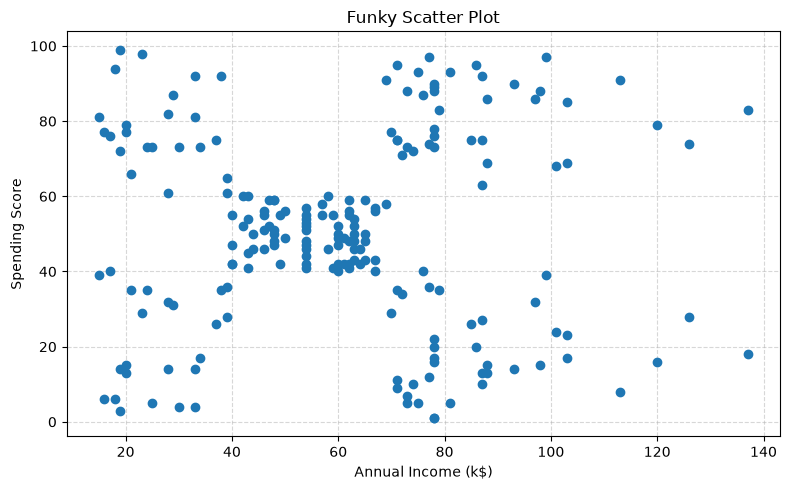

In [6]:
fig, ax = plt.subplots(figsize = (8,5))

ax.scatter(x=df1['Annual Income (k$)'],
           y=df1['Spending Score (1-100)'],
           zorder = 3)

ax.set(title="Funky Scatter Plot",
       xlabel="Annual Income (k$)",
       ylabel="Spending Score")

ax.grid(alpha = 0.5,
        linestyle ="--",
        zorder=1)

plt.tight_layout()
plt.show()

#### KMeans Demonstration

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

##### Preparing the Data

We want to prepare the data for KMeans clustering. There is not much to do, mainly we should scale the data, convert any type(str) variables into numerical values (only if it makes sense eg. binary, ordinal) and set the KMeans model.

Note: 
+ It is always better to scale your data if your model relies on Euclidean distance (eg. KNN, kmeans). A variable with a large scale can overwhelm other variables on a smaller scale. 

In [8]:
## Obtain the columns that we want
df1_demo = df1[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']].copy()

## Convert to binary
df1_demo['Gender'] = np.where(df1_demo['Gender'] == 'Male', 1, 0)
df1_demo = df1_demo.rename(columns={'Gender': 'is_male'})

In [9]:
print(df1_demo.head())

   is_male  Age  Annual Income (k$)  Spending Score (1-100)
0        1   19                  15                      39
1        1   21                  15                      81
2        0   20                  16                       6
3        0   23                  16                      77
4        0   31                  17                      40


In [10]:
# If possible, scale the data before using KMeans, as it relies on Euclidean distance
scaler = StandardScaler()
df1_scaled = scaler.fit_transform(df1_demo)

KMeans Paramters (for sklearn):
+ n_clusters: the number of clusters centroids that you desire
+ random_state: ensure replicability
+ n_init: the number of times the algorithm is run with different seeds (hill-climb optimisation)
+ tol: default = 1e-4. The Frobenius norm of the difference in cluster centers of two consecutive iterations to declare convergence. (Think of it as: if the movement in cluster centroid is below `tol`, then we can declare that we have reached the optimal clustering of data points)

In [11]:
## This step creates an instance of the KMeans model
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
kmeans.fit(df1_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 4)","[

In [12]:
print("Cluster Labels:", kmeans.labels_) 

Cluster Labels: [2 2 4 4 4 4 4 4 0 4 0 4 0 4 0 2 4 2 0 4 2 2 0 2 0 2 0 2 4 4 0 4 0 2 0 4 0
 4 4 4 0 2 0 4 0 4 0 4 4 4 0 2 4 0 0 0 0 0 4 0 0 2 0 0 0 2 4 0 2 4 0 0 0 0
 0 2 3 2 4 0 0 2 0 3 4 0 0 4 4 0 0 2 0 3 4 2 3 4 0 2 4 3 0 2 0 4 0 0 0 0 0
 4 3 2 4 4 0 3 3 3 2 3 3 2 3 3 1 2 1 2 1 2 3 3 1 3 3 2 1 3 0 2 3 3 1 2 1 3
 3 2 1 2 3 3 3 3 1 3 1 3 3 3 1 3 1 3 1 3 3 2 1 2 1 2 3 3 1 2 1 2 3 3 1 3 3
 2 3 2 3 3 3 3 1 3 3 3 3 2 1 2]


In [13]:
df1_demo['Label'] = kmeans.labels_
print(df1_demo.head())

   is_male  Age  Annual Income (k$)  Spending Score (1-100)  Label
0        1   19                  15                      39      2
1        1   21                  15                      81      2
2        0   20                  16                       6      4
3        0   23                  16                      77      4
4        0   31                  17                      40      4


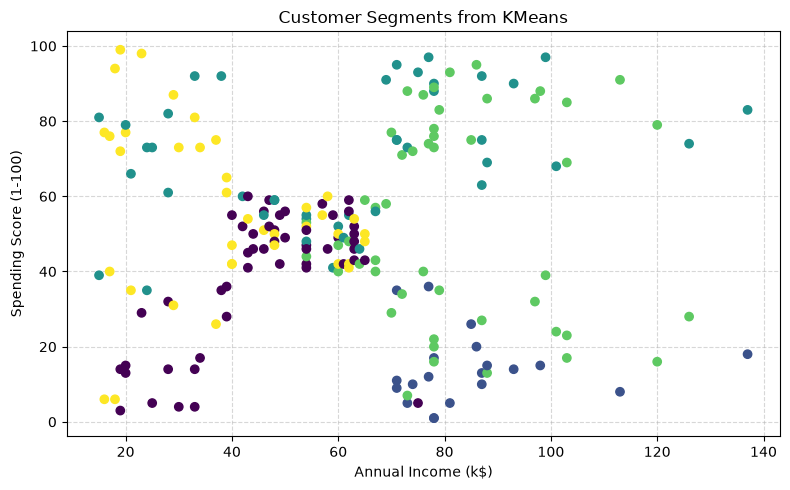

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=df1_demo['Annual Income (k$)'],
    y=df1_demo['Spending Score (1-100)'],
    c=df1_demo['Label'],
    cmap='viridis',
    zorder=3
)

ax.set(
    title='Customer Segments from KMeans',
    xlabel='Annual Income (k$)',
    ylabel='Spending Score (1-100)'
)
ax.grid(alpha=0.5, linestyle='--', zorder=1)
plt.tight_layout()
plt.show()

Why does it look so bad? 

+ We are projecting multi-dimensional data into a plane 
+ Data are grouped in 'data clouds' in the hyperplane. 
+ We can remove some variables to see better clusters

In [15]:
print("Centroids:\n", kmeans.cluster_centers_)

Centroids:
 [[ 0.14062401  1.26457129 -0.55200479 -0.42262217]
 [ 1.12815215  0.04664835  0.93858626 -1.40339942]
 [ 1.12815215 -0.72911539  0.01315937  0.77791013]
 [-0.88640526 -0.06832482  0.82302637  0.16495202]
 [-0.88640526 -0.82777211 -0.82895964  0.23333801]]


In [ ]:
new_customer = pd.DataFrame([{
    'is_male': 1, # male
    'Age': 23, # 23 Years Old
    'Annual Income (k$)': 40, # Annual Income of 40k
    'Spending Score (1-100)': 60
}])

new_scaled = scaler.transform(new_customer)
cluster_label = int(kmeans.predict(new_scaled)[0]) ## this returns a list with 1 element, so select the element with [0] and convert to int

print(f"New Customer Belongs to Cluster {cluster_label}")

new_customer.assign(Cluster=cluster_label)

New Customer Belongs to Cluster 2


,is_male,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,23,40,60,2


#### Plotting the Scree Plot

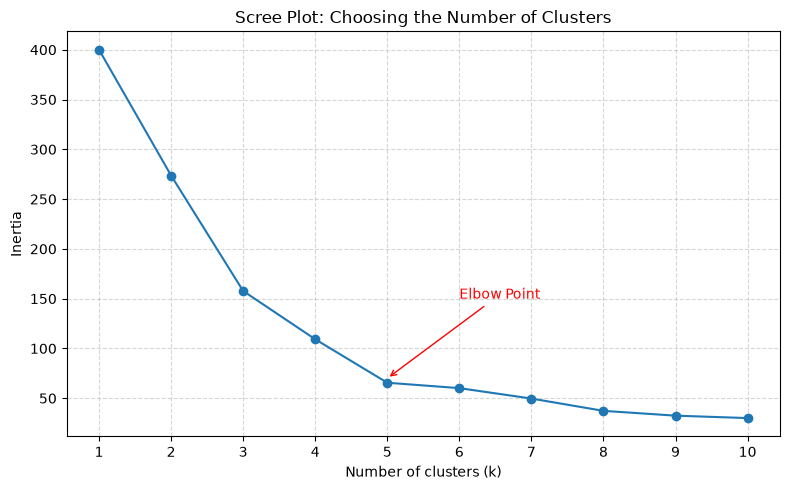

In [ ]:
# Set a range of clusters that you want to test
cluster_range = range(1, 11)
inertias = []

for n in cluster_range:
    model = KMeans(n_clusters=n, random_state=42,n_init='auto')
    model.fit(df1_scaled)
    inertias.append(model.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cluster_range, inertias, marker='o')
ax.set(
    title='Scree Plot: Choosing the Number of Clusters',
    xlabel='Number of clusters (k)',
    ylabel='Inertia'
)
ax.set_xticks(list(cluster_range))
ax.grid(alpha=0.5, linestyle='--')

# Add annotations
ax.annotate("Elbow Point", 
            xy=(5,70), 
            xytext=(6, 150),
            arrowprops={'arrowstyle': '->', 'color':'red'},
            color = 'red')

plt.tight_layout()
plt.show()

##### Better Visualisation

   Annual Income (k$)  Spending Score (1-100)  Label
0                  15                      39      4
1                  15                      81      2
2                  16                       6      4
3                  16                      77      2
4                  17                      40      4


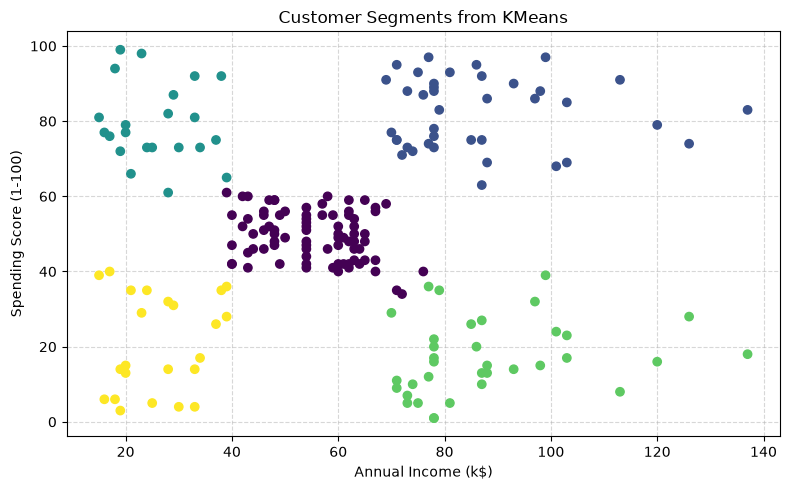

Centroids:
 [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


In [21]:
## Obtain the columns that we want
df1_demo = df1[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

## Scaling
df1_scaled = scaler.fit_transform(df1_demo)

## Fit the KMeans Model
kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
kmeans.fit(df1_scaled)

## Get labels
df1_demo['Label'] = kmeans.labels_
print(df1_demo.head())

## Plot the Graph
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=df1_demo['Annual Income (k$)'],
    y=df1_demo['Spending Score (1-100)'],
    c=df1_demo['Label'],
    cmap='viridis',
    zorder=3
)

ax.set(
    title='Customer Segments from KMeans',
    xlabel='Annual Income (k$)',
    ylabel='Spending Score (1-100)'
)
ax.grid(alpha=0.5, linestyle='--', zorder=1)
plt.tight_layout()
plt.show()

print("Centroids:\n", kmeans.cluster_centers_)

##### Challenge: Try applying DBSCAN to this dataset yourself!

### DBSCAN

In [26]:
path = kagglehub.dataset_download("berkayalan/sklearn-moons-data-set")
print("Path to dataset files:", path)

data_dir = Path(path)
print(list(data_dir.iterdir()))


file_path = data_dir / "cluster_moons.csv"

Path to dataset files: /Users/chowchow/.cache/kagglehub/datasets/berkayalan/sklearn-moons-data-set/versions/1
[PosixPath('/Users/chowchow/.cache/kagglehub/datasets/berkayalan/sklearn-moons-data-set/versions/1/cluster_moons.csv')]


#### Reading and Understanding the dataset

In [27]:
df2 = pd.read_csv(file_path)
print(df2.head())

         X1        X2
0  0.674362 -0.444625
1  1.547129 -0.239796
2  1.601930 -0.230792
3  0.014563  0.449752
4  1.503476 -0.389164


Notes: This dataset just contains coordinates to half-circles in R2

#### What happens if we just apply KMeans to this?

         X1        X2  Label
0  0.674362 -0.444625      1
1  1.547129 -0.239796      1
2  1.601930 -0.230792      1
3  0.014563  0.449752      0
4  1.503476 -0.389164      1


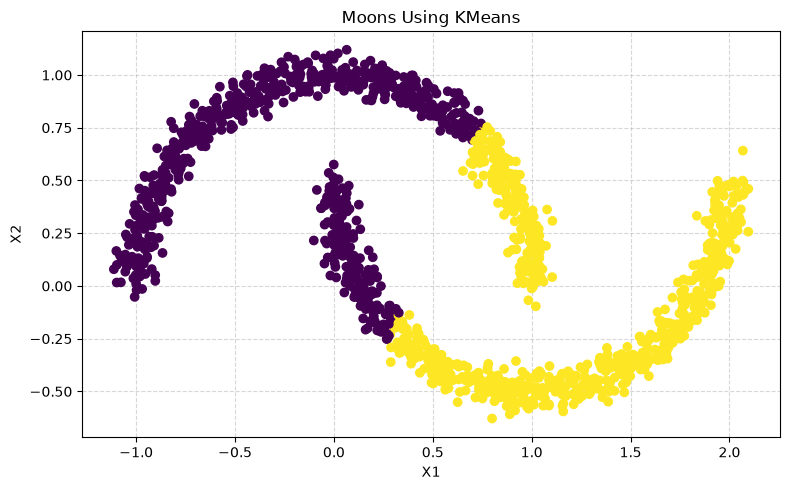

Centroids:
 [[-0.19810638  0.57233752  0.        ]
 [ 1.20634392 -0.07402291  0.        ]]


In [39]:
df2_kmeans = df2.copy()

## Not scaling here to preserve the shaoe of the half moons

kmeans = KMeans(n_clusters=2, random_state=42, n_init="auto")
kmeans.fit(df2_kmeans)

df2_kmeans['Label'] = kmeans.labels_
print(df2_kmeans.head())

## Plot the Graph
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=df2_kmeans['X1'],
    y=df2_kmeans['X2'],
    c=df2_kmeans['Label'],
    cmap='viridis',
    zorder=3
)

ax.set(
    title='Moons Using KMeans',
    xlabel='X1',
    ylabel='X2'
)
ax.grid(alpha=0.5, linestyle='--', zorder=1)
plt.tight_layout()
plt.show()

print("Centroids:\n", kmeans.cluster_centers_)

#### DBSCAN Demonstration

In [36]:
from sklearn.cluster import DBSCAN

df2_db = df2.copy()

DBSCAN Paramters (for sklearn):
+ eps: (default=0.5) The maximum distance between two samples for one to be considered as in the neighborhood of the other.
+ min_sample: (default=5) The number of data points in a neighborhood for a point to be considered as a core point.
+ metric: (default='euclidean') The metric to use when calculating distance between instances in a feature array.


There are others: 
+ algorithm: {‘auto’, ‘ball_tree’, ‘kd_tree’, ‘brute’}
+ leaf_size: Leaf size passed to BallTree or cKDTree
+ p: The power of the Minkowski metric to be used to calculate distance between points. If None, then p=2 (equivalent to the Euclidean distance).
+ n_jobs: The number of parallel jobs to run.

But these are not as important as the first 3. Feel free to read up on them if you are interested

In [47]:
# This creates an instance of the DBSCAN model
db = DBSCAN(eps=0.2, min_samples=3, metric='euclidean')
db.fit(df2_db)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",0.2
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](1500, 3)","[[ 0.67,-0.44, 0. ], [ 1.55,-0.24, 0. ], [ 1.6 ,-0.23, 0. ], ..., [-0.76, 0.58, 1. ], [ 1.8 ,-0.15, 0. ], [ 0.2 , 0.08, 0. ]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](1500,)","[ 0, 1, 2,...,1497,1498,1499]"


In [48]:
## Similar to KMeans, DBSCAN assigns a cluster label to each data point
labels = db.labels_
df2_db['Label'] = labels # we assign each data point to its cluster

n_clusters = len(set(labels)) - (1 if -1 in labels else 0) ## Calculate the number of unique labels
print(n_clusters)

2


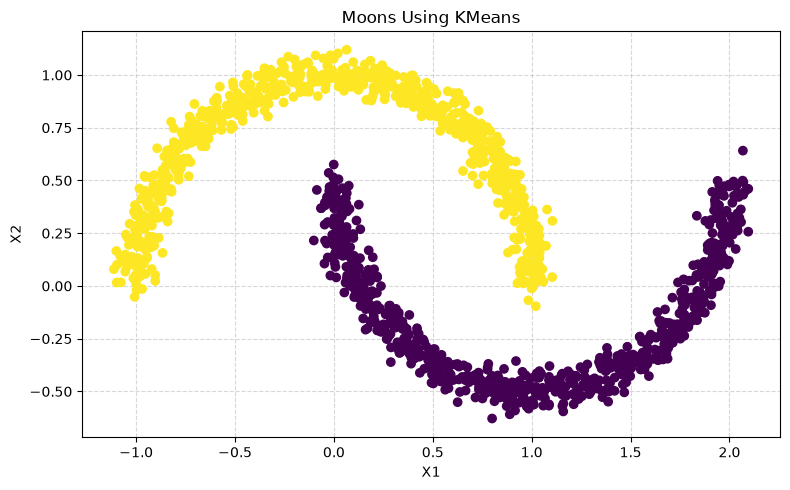

In [49]:
## Plot the Graph
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    x=df2_db['X1'],
    y=df2_db['X2'],
    c=df2_db['Label'],
    cmap='viridis',
    zorder=3
)

ax.set(
    title='Moons Using KMeans',
    xlabel='X1',
    ylabel='X2'
)
ax.grid(alpha=0.5, linestyle='--', zorder=1)
plt.tight_layout()
plt.show()